# Gaussian Mixture Modeling Regimes

In [3]:
from sklearn.mixture import GaussianMixture
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
residuals = pd.read_csv('../data/manipulated/pr_filtered_train_residuals.csv', index_col=0, parse_dates=True)
cointegration_pairs = pd.read_csv('../data/manipulated/cointegrated_pairs.csv')

In [5]:
cointegration_pairs.head()

,asset_a,asset_b,pvalue,beta
0,CDW,AMCR,0.0,1.092865
1,NKE,LIN,0.0,0.819010
2,ECL,ACN,0.0,0.912121
3,ECL,HON,0.0,0.879076
4,ARES,CSX,0.0,0.823952


In [6]:
def plot_bic(
        spread: pd.Series,
        k_range: range = [2, 3, 4, 5]
        ) -> None:
        """
        Plot the Bayesian Information Criterion (BIC) for different numbers of components in a Gaussian Mixture Model.
        """

        X = spread.values.reshape(-1, 1)
        bic_scores = []

        for k in k_range:
                gmm = GaussianMixture(
                n_components=k,
                covariance_type="full",
                random_state=42,
                n_init=5,
                )
                gmm.fit(X)
                bic_scores.append((k, gmm.bic(X)))

        plt.plot([k for k, _ in bic_scores], [bic for _, bic in bic_scores], marker='o')
        plt.title('BIC Scores for GMM')
        plt.xlabel('Number of Components (k)')
        plt.ylabel('BIC Score')
        plt.xticks([k for k, _ in bic_scores])
        plt.grid()
        plt.show()

In [7]:
def select_best_k(
    spread: pd.Series,
    k_range: range = [2, 3, 4, 5],
    ) -> int:
    """
    Select the optimal number of GMM components using BIC.

    Lower BIC => better model.

    Args:
        spread:  1D spread time series (training portion only).
        k_range: Range of k values to evaluate.

    Returns:
        best_k:  Optimal number of components.
    """
    X = spread.values.reshape(-1, 1)
    bic_scores = []

    for k in k_range:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=42,
            n_init=5,
        )
        gmm.fit(X)
        bic_scores.append((k, gmm.bic(X)))

    best_k = min(bic_scores, key=lambda x: x[1])[0]
    return best_k

In [8]:
def fit_gmm(
    spread: pd.Series,
    n_components: int,
) -> GaussianMixture:
    """
    Fit a GaussianMixture model to a spread series.

    Args:
        spread:       1D spread time series.
        n_components: Number of Gaussian components (regimes).

    Returns:
        Fitted GaussianMixture object.
    """
    X = spread.values.reshape(-1, 1)
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        random_state=42,
        n_init=5,
    )
    gmm.fit(X)
    return gmm

### Visualise spread regimes for first 5 pairs

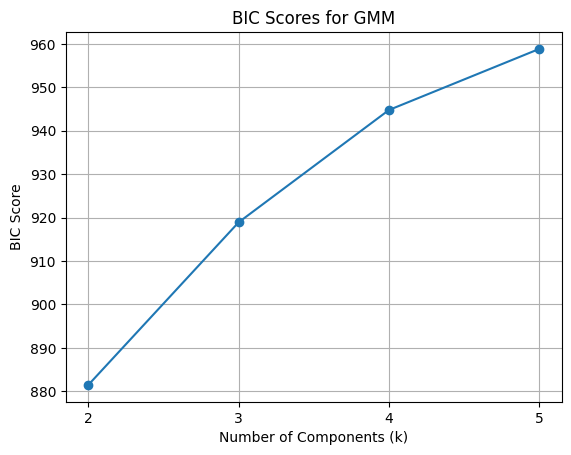

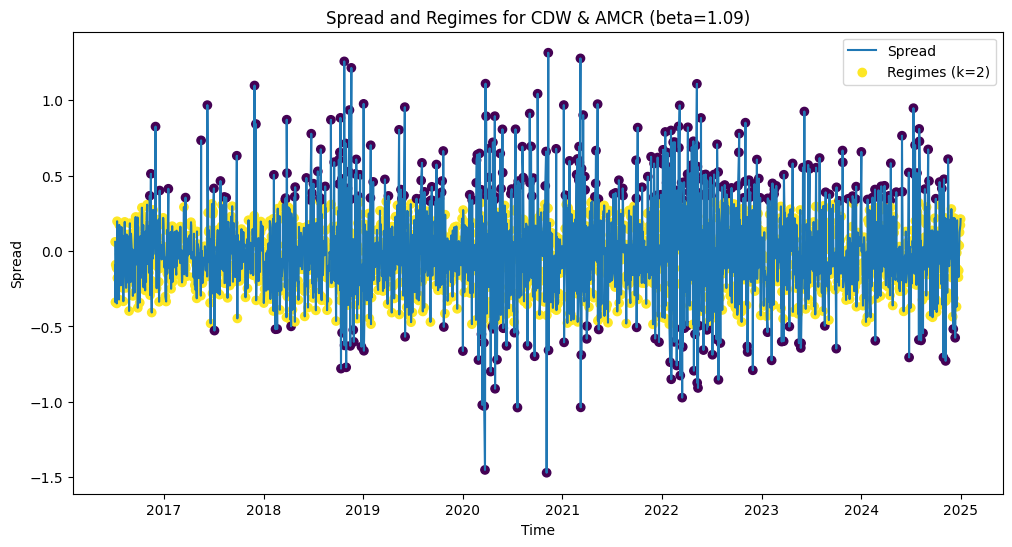

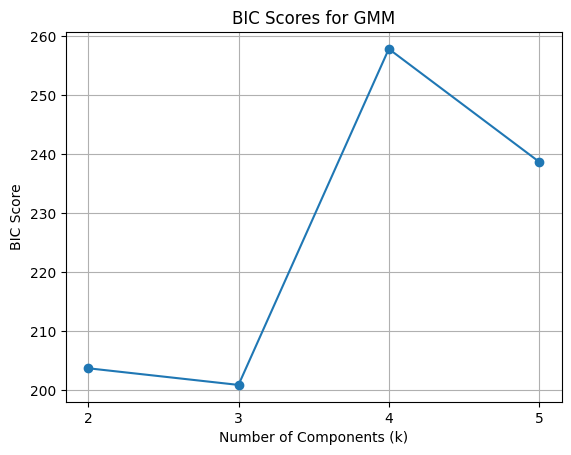

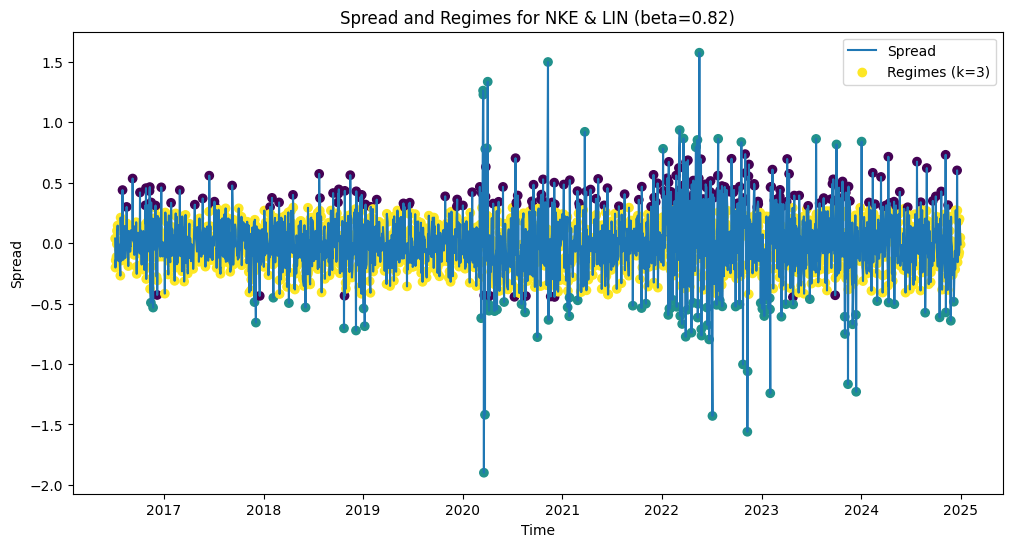

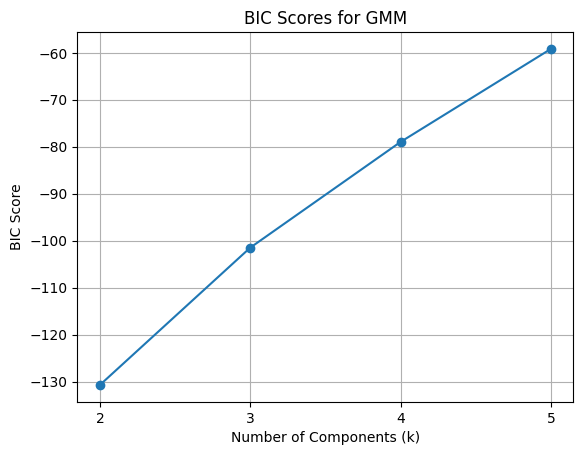

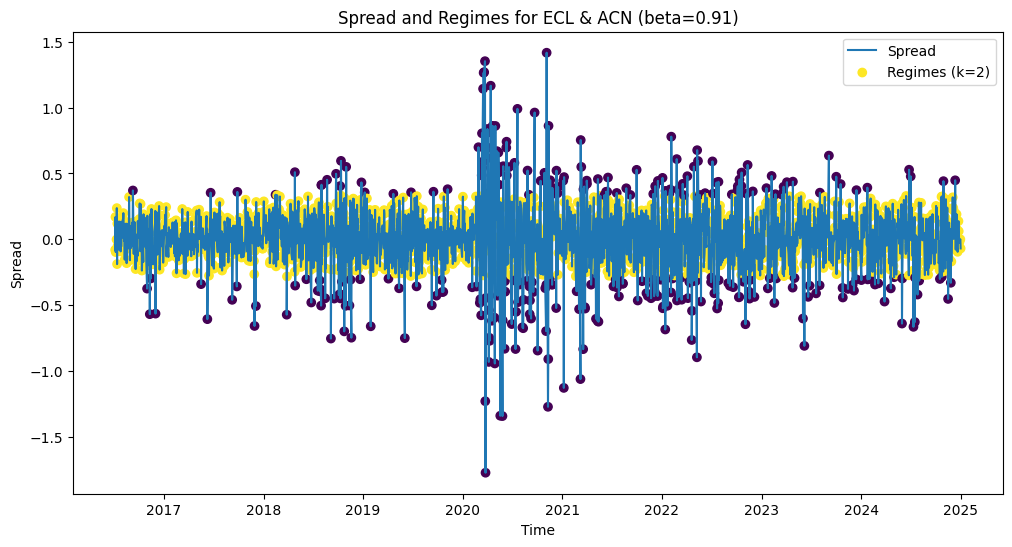

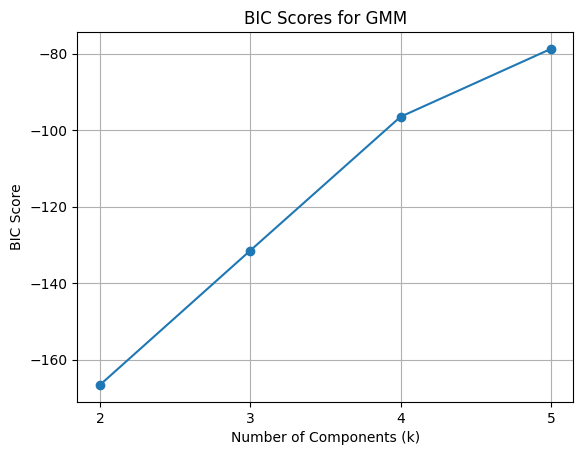

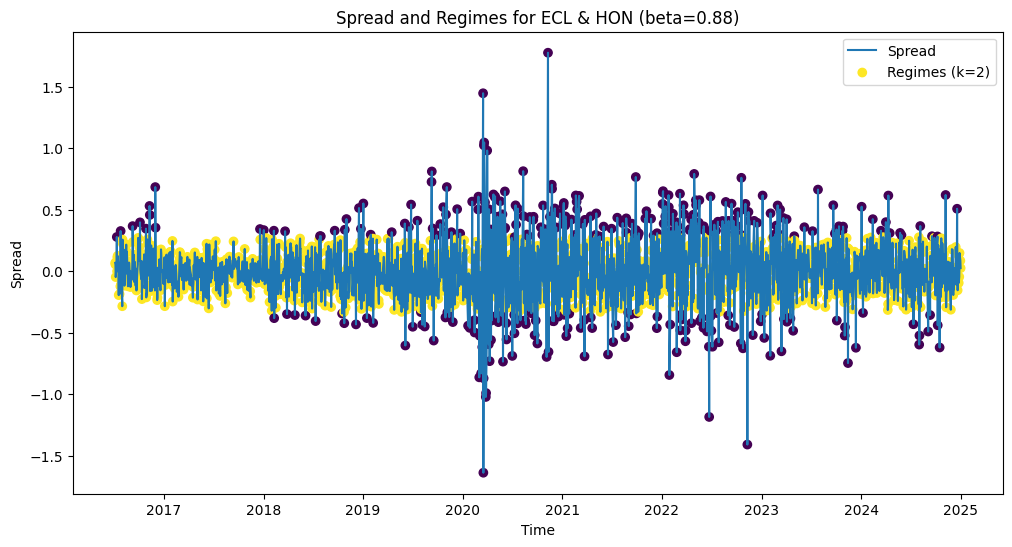

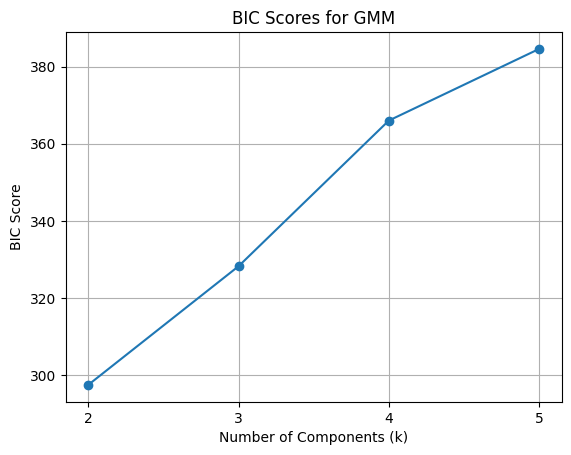

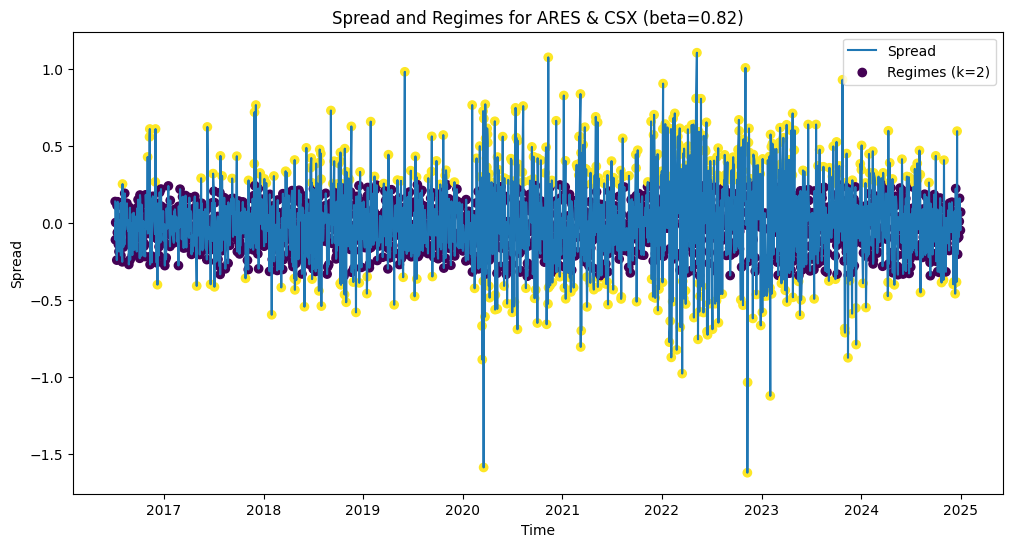

In [9]:
for i, row in cointegration_pairs.iterrows():
    a = row['asset_a']
    b = row['asset_b']
    beta = row['beta']
    
    spread = residuals[a] - beta * residuals[b]

    best_k = select_best_k(spread)
    gmm = fit_gmm(spread, best_k)
    plot_bic(spread)

    regimes = gmm.predict(spread.values.reshape(-1, 1))
    plt.figure(figsize=(12, 6))
    plt.plot(spread.index, spread.values, label='Spread')
    plt.scatter(spread.index, spread.values, c=regimes, label=f'Regimes (k={best_k})', cmap='viridis', marker='o')
    plt.title(f'Spread and Regimes for {a} & {b} (beta={beta:.2f})')
    plt.xlabel('Time')
    plt.ylabel('Spread')
    plt.legend()
    plt.show()

    if i >= 4:
        break

### Save spreads with regime labels and signals

For each pair: compute spread, fit GMM, assign regimes, compute global z-score, generate signals. Only enter trades in the calm regime (lowest std).

In [10]:
os.makedirs('../data/manipulated/spreads', exist_ok=True)

for _, row in cointegration_pairs.iterrows():
    a, b, beta = row['asset_a'], row['asset_b'], row['beta']
    
    spread = residuals[a] - beta * residuals[b]
    
    best_k = select_best_k(spread)
    gmm    = fit_gmm(spread, best_k)
    labels = gmm.predict(spread.values.reshape(-1, 1))
    
    # sort regimes by mean for consistency across pairs
    sorted_idx    = np.argsort(gmm.means_.flatten())
    remap         = {old: new for new, old in enumerate(sorted_idx)}
    sorted_labels = np.array([remap[l] for l in labels])
    
    # global z-score
    z_scores = (spread - spread.mean()) / spread.std()
    
    # calm regime = lowest std after sorting
    sorted_stds = np.sqrt(gmm.covariances_.flatten())[sorted_idx]
    calm_regime = int(np.argmin(sorted_stds))
    
    # signals: only enter in calm regime
    signal = pd.Series(0, index=spread.index)
    signal[(z_scores < -1) & (sorted_labels == calm_regime)] =  1
    signal[(z_scores >  1) & (sorted_labels == calm_regime)] = -1
    signal[z_scores.abs() < 0.2] = 0
    
    df = pd.DataFrame({
        'spread':  spread.values,
        'regime':  sorted_labels,
        'z_score': z_scores.values,
        'signal':  signal.values,
    }, index=spread.index)
    
    df.to_csv(f'../data/manipulated/spreads/{a}_{b}.csv')

print(f'saved {len(cointegration_pairs)} spread files')

saved 300 spread files


### Check signal distributions

In [11]:
for i, row in cointegration_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    df = pd.read_csv(f'../data/manipulated/spreads/{a}_{b}.csv', index_col=0)

    print(f'Signal Distribution for {a} & {b}:')
    print(df['signal'].value_counts().sort_index())
    print()

    if i >= 19:
        break

Signal Distribution for CDW & AMCR:
signal
-1      23
 0    1931
 1     183
Name: count, dtype: int64

Signal Distribution for NKE & LIN:
signal
-1      39
 0    1946
 1     152
Name: count, dtype: int64

Signal Distribution for ECL & ACN:
signal
-1     110
 0    1982
 1      45
Name: count, dtype: int64

Signal Distribution for ECL & HON:
signal
-1      56
 0    1965
 1     116
Name: count, dtype: int64

Signal Distribution for ARES & CSX:
signal
0    2028
1     109
Name: count, dtype: int64

Signal Distribution for ARES & WY:
signal
0    2003
1     134
Name: count, dtype: int64

Signal Distribution for ARES & DIS:
signal
-1     139
 0    1957
 1      41
Name: count, dtype: int64

Signal Distribution for ARES & ACN:
signal
0    2137
Name: count, dtype: int64

Signal Distribution for CBRE & CRH:
signal
0    1997
1     140
Name: count, dtype: int64

Signal Distribution for CBRE & WY:
signal
-1      98
 0    2005
 1      34
Name: count, dtype: int64

Signal Distribution for ARES & HON:
s

### Check z-score statistics

In [12]:
for i, row in cointegration_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    df = pd.read_csv(f'../data/manipulated/spreads/{a}_{b}.csv', index_col=0)
    print(f'Z-Score Statistics for {a} & {b}:')
    print(df['z_score'].describe())
    print(df['z_score'].abs().quantile([0.8, 0.9, 0.95, 0.99]))
    print()

    if i >= 9:
        break

Z-Score Statistics for CDW & AMCR:
count    2.137000e+03
mean    -9.974863e-18
std      1.000000e+00
min     -4.816523e+00
25%     -5.649284e-01
50%     -5.163727e-02
75%      5.303968e-01
max      4.300115e+00
Name: z_score, dtype: float64
0.80    1.181850
0.90    1.597359
0.95    2.091716
0.99    3.081318
Name: z_score, dtype: float64

Z-Score Statistics for NKE & LIN:
count    2.137000e+03
mean    -1.329982e-17
std      1.000000e+00
min     -7.130846e+00
25%     -5.320938e-01
50%     -3.247613e-02
75%      5.454869e-01
max      5.918735e+00
Name: z_score, dtype: float64
0.80    1.121211
0.90    1.556145
0.95    1.969126
0.99    3.116355
Name: z_score, dtype: float64

Z-Score Statistics for ECL & ACN:
count    2.137000e+03
mean     1.163734e-17
std      1.000000e+00
min     -7.037658e+00
25%     -5.001535e-01
50%      3.853374e-02
75%      5.312323e-01
max      5.626236e+00
Name: z_score, dtype: float64
0.80    1.078082
0.90    1.496598
0.95    2.004882
0.99    3.395237
Name: z_score

The z-score statistics for most pairs appear to be approximately standard normal. The good news is that this means the GMM regimes are very well separated, meaning each spread within a regime looks normal to that regime. The bad news is that this means z-scoring within regimes is not feasible for signaling, so I will instead implement global z-scoring across all regimes and then use the regimes as volatility indicators, e.g. an extreme z-score + a stable regime means we expect the spread to stabilize.

For now, classify the lowest stdev regime as the calm one and trade in it only.

Much more desirable split now.